# Docker

Docker ek tool hai jo application aur uski saari dependencies ko ek package (container) mein pack kar deta hai, taaki application har system par same tarike se run kare.

# Problem Without Docker

Maan lo tumne apne laptop par project banaya.

Python 3.12

FastAPI

Pandas

NumPy

Tum project dost ko dete ho.

Uske system mein:

Python 3.10

Different packages

Result:

❌ Project run nahi hoga

❌ Dependency issues

❌ Version conflicts

# Solution: Docker

Docker application ke saath sab kuch pack kar deta hai.

Application
     +
Python
     +
Libraries
     +
Dependencies
     ↓
Docker Container

Ab ye container kisi bhi machine par chalega.

# Why Do We Need Docker?

We need Docker to make sure our application runs the same way on every machine without dependency or environment issues.

# 1. Consistency

# 2. Easy Deployment

Deploy applications quickly on servers and cloud platforms.

# 3. Dependency Management

No need to install packages manually.

# 4. Isolation

Each application runs in its own container.

App 1 → Own Container

App 2 → Own Container

No conflicts.

# 5. Scalability

Easy to create multiple copies of the same application.

Container 1

Container 2

Container 3

Useful for high traffic.

# How Exactly Docker Is Used?

Suppose tumne ek FastAPI ML Project banaya hai.

Normally:

Code
↓
Install Python
↓
Install FastAPI
↓
Install Pandas
↓
Install NumPy
↓
Run Project

Har machine par ye sab manually karna padega.

# But when we used docker

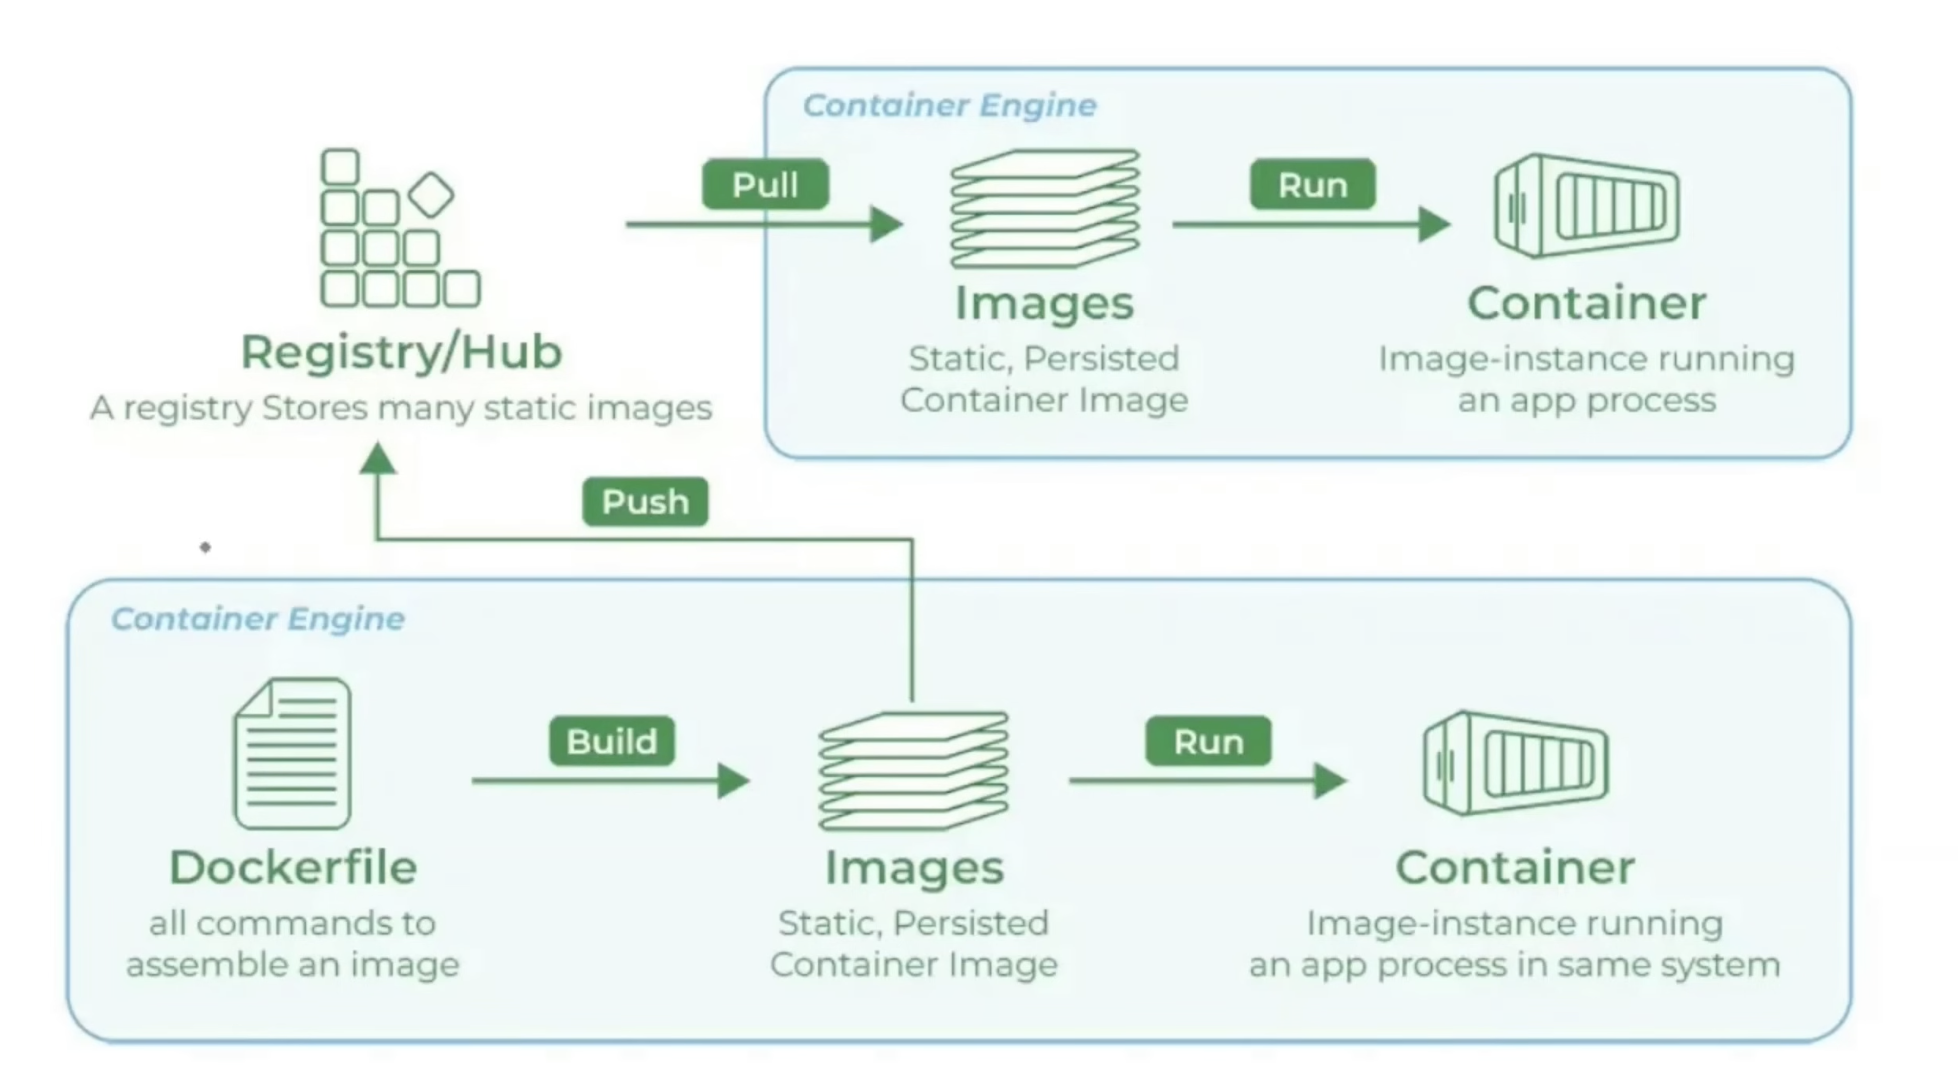

# Docker Approach

In [ ]:
# Step 1: Write Your App
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Hello Docker"}

In [ ]:
# Step 2: Create Dockerfile

# Docker ko instructions dete hain:

FROM python:3.12

WORKDIR /app

COPY . .

RUN pip install -r requirements.txt

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

# Meaning:

Use Python 3.12
↓
Copy my code
↓
Install dependencies
↓
Start FastAPI

In [ ]:
# Step 3: Build an Image
docker build -t fastapi-app .

# Docker image ban jayegi.

Code
+
Python
+
Libraries
+
Dependencies
↓
Docker Image

In [ ]:
# Step 4: Run a Container
docker run -p 8000:8000 fastapi-app

# Container start ho jayega.

Docker Image
      ↓
Docker Container
      ↓
Running Application

# Real Flow in Companies
Developer Writes Code
          ↓
Create Docker Image
          ↓
Push Image to Registry
          ↓
Server Pulls Image
          ↓
Run Container
          ↓
Application Live

# Docker Engine
Docker Engine Docker ka main software hai jo containers ko create, run, stop aur manage karta hai.

# Docker Engine is the core runtime of Docker that is responsible for building, running, and managing containers. It consists of the Docker Daemon, Docker CLI, and REST API, which work together to create and manage containerized applications.

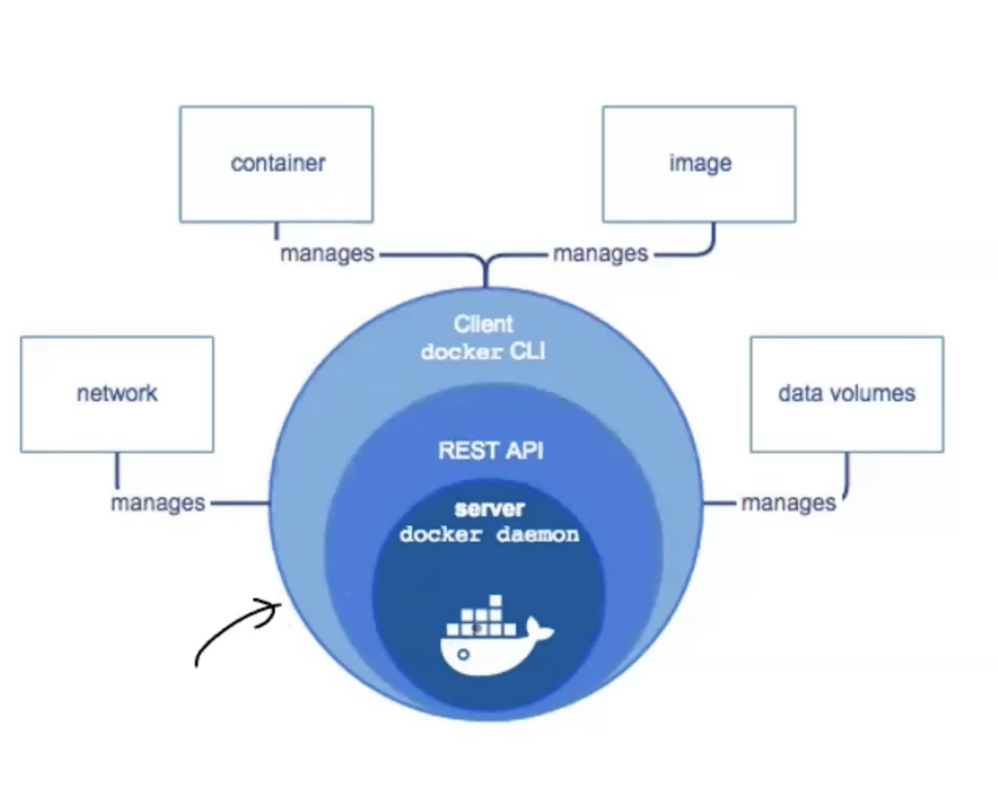

# Docker Engine  Main Components

# 1. Docker Daemon (dockerd)

Background mein run karta hai.

Kaam:

Create Container

Start Container

Stop Container

Delete Container

# Functions

Docker Daemon (dockerd) Docker ka main background service hota hai jo containers, images, networks aur volumes ko manage karta hai. Ye container create karna, start karna, stop karna, image build karna aur Docker resources ko maintain karne ka kaam karta hai. Simple words mein, Docker Daemon Docker ke saare operations ko execute karta hai.

# Interaction
Jab user Docker CLI mein koi command deta hai, jaise docker run fastapi-app, to Docker CLI us request ko Docker Daemon tak bhejta hai. Docker Daemon command ko process karta hai aur required action perform karta hai, jaise container create karke application ko run karna. Simple words mein, Docker CLI user se command leta hai aur Docker Daemon actual kaam karke result provide karta hai.

# 2. Docker CLI

Command line jahan hum commands likhte hain.

Example:

docker run nginx

docker ps

docker stop container_id

# Function

Docker CLI (Command Line Interface) ek tool hai jiske through user Docker ke saath interact karta hai. Ye user ki commands jaise docker run, docker build, docker pull, aur docker stop ko receive karta hai aur Docker Daemon tak pahunchata hai. Simple words mein, Docker CLI user aur Docker Daemon ke beech communication ka medium hai.

# Usage

Docker CLI ka use containers ko create, run, stop, delete karne aur images ko build ya download karne ke liye kiya jata hai. Jab developer Docker par koi operation perform karna chahta hai, to wo Docker CLI commands use karta hai. Simple words mein, Docker CLI Docker ko control karne ka interface hai jiske through hum saare Docker operations perform karte hain.

# 3. REST API

CLI aur Docker Daemon ke beech communication karwati hai.

Flow:

Docker CLI
     ↓
REST API
     ↓
Docker Daemon
     ↓
Container

# Function

Docker REST API ek communication layer hoti hai jo Docker CLI aur Docker Daemon ke beech data exchange karwati hai. Ye API HTTP requests ke through Docker commands ko Daemon tak pass karti hai aur responses wapas CLI ko deti hai. Simple words mein, REST API ek bridge hai jo Docker ke components ko connect karta hai.

# Usage
Docker REST API ka use programmatically Docker ko control karne ke liye hota hai. Developers is API ka use karke containers create, manage aur monitor kar sakte hain bina CLI use kiye. Simple words mein, REST API Docker operations ko code ke through automate karne ke liye use hoti hai.

# Docker Image

Docker Image ek ready-made package hota hai jisme app, uski settings, aur saari libraries already packed hoti hain, jisse hum easily container bana sakte hain.

# Technical Meaning (Simple)

Code + Libraries + Dependencies + Config
                ↓
           Docker Image

# Key Point
Docker Image = Static (ready package)

Docker Container = Running version of image

# Docker Image Lifecycle

Docker Image Lifecycle ka matlab hota hai image ka start se leke use hone aur store/share hone tak ka pura flow.

# 1. Create Image:
Sabse pehle developer apna application aur dependencies ko ek Dockerfile mein define karta hai. Uske baad docker build command se Docker Image create hoti hai.

# 2. Store Image:
Banayi hui Docker Image ko local system ya cloud registry (jaise Docker Hub) mein store kiya jata hai taaki use baad mein use ya share kiya ja sake.

# 3. Pull Image:
Agar image cloud registry mein hai to use docker pull command se kisi bhi machine par download kiya jata hai.

# 4. Run Container:
Docker Image ko use karke container create kiya jata hai using docker run command. Is step mein image actual running application ban jati hai.

# 5. Update / Rebuild Image:
Agar code mein changes hote hain to image ko dobara build kiya jata hai aur new version create hota hai.

# Dockerfile
Dockerfile ek simple text file hoti hai jisme instructions likhe hote hain ki Docker image kaise banani hai.

* Dockerfile kya karta hai?

Code + Instructions
        ↓
     Dockerfile
        ↓
     Docker Image
        ↓
     Container

In [ ]:
# Simple Dockerfile Example
FROM python:3.12

WORKDIR /app

COPY . .

RUN pip install -r requirements.txt

CMD ["python", "main.py"]

# Line by Line Meaning
* 1. FROM

Base system choose karta hai

**Example:
Python 3.12 install karo**
* 2. WORKDIR

Project folder set karta hai
* 3. COPY

Code ko Docker ke andar copy karta hai
* 4. RUN

Dependencies install karta hai
* 5. CMD

Application start karta hai

* 6.  LABEL (Metadata)

LABEL ka use image ke baare mein extra information (metadata) dene ke liye hota hai.

* 7. ENV (Environment Variables)

ENV ka use variables set karne ke liye hota hai jo container ke andar use hote hain.

# Example

ENV PORT=8000

ENV ENVIRONMENT=production

* 8. COPY (Files Transfer)

COPY ka use local machine se files ko Docker image ke andar copy karne ke liye hota hai.

# Example
COPY . /app

* 9. VOLUME (Data Save karna)

VOLUME ka use data ko permanently save karne ke liye hota hai, even agar container delete ho jaye

# Example
VOLUME /data

* 10. ARG (Build Time Variable)

ARG ka use image build karte time values pass karne ke liye hota hai.

# Example

ARG VERSION=1.0

# Build command
docker build --build-arg VERSION=2.0



# Docker Container

Docker Container ek running application hota hai jo Docker Image se banaya jata hai.

# Docker Registry

Docker Registry ek online storage hota hai jahan Docker images ko store, share aur download kiya jata hai.

# Example

* Tumne ek Docker image banayi:

fastapi-app:1.0

* Ab tum ise upload karte ho registry par:

docker push fastapi-app

* Aur koi dusra banda use download karta hai:

docker pull fastapi-app



# Types of Registries
# 1. Public Registry
Sab use kar sakte hain

Example:

Docker Hub
# 2. Private Registry
Sirf company ya team use karti hai

Example:

Amazon Elastic Container Registry

Google Artifact Registry

# Benefits of Using Docker Registry

1. Easy Sharing

2. Central Storage

3. Easy Deployment
4. Version Control

5. Consistency
6. CI/CD Integration
7. Backup & Safety

# CI/CD

CI/CD ek automation process hai jo code ko build, test aur deploy karne ko fast aur automatic bana deta ha

1. CI (Continuous Integration)

CI ka matlab hai code ko baar-baar integrate (merge) karke automatically test karna.

2. CD (Continuous Delivery / Deployment)

Code ready ho jata hai deploy ke liye, but manual approval hota hai.



# Setup

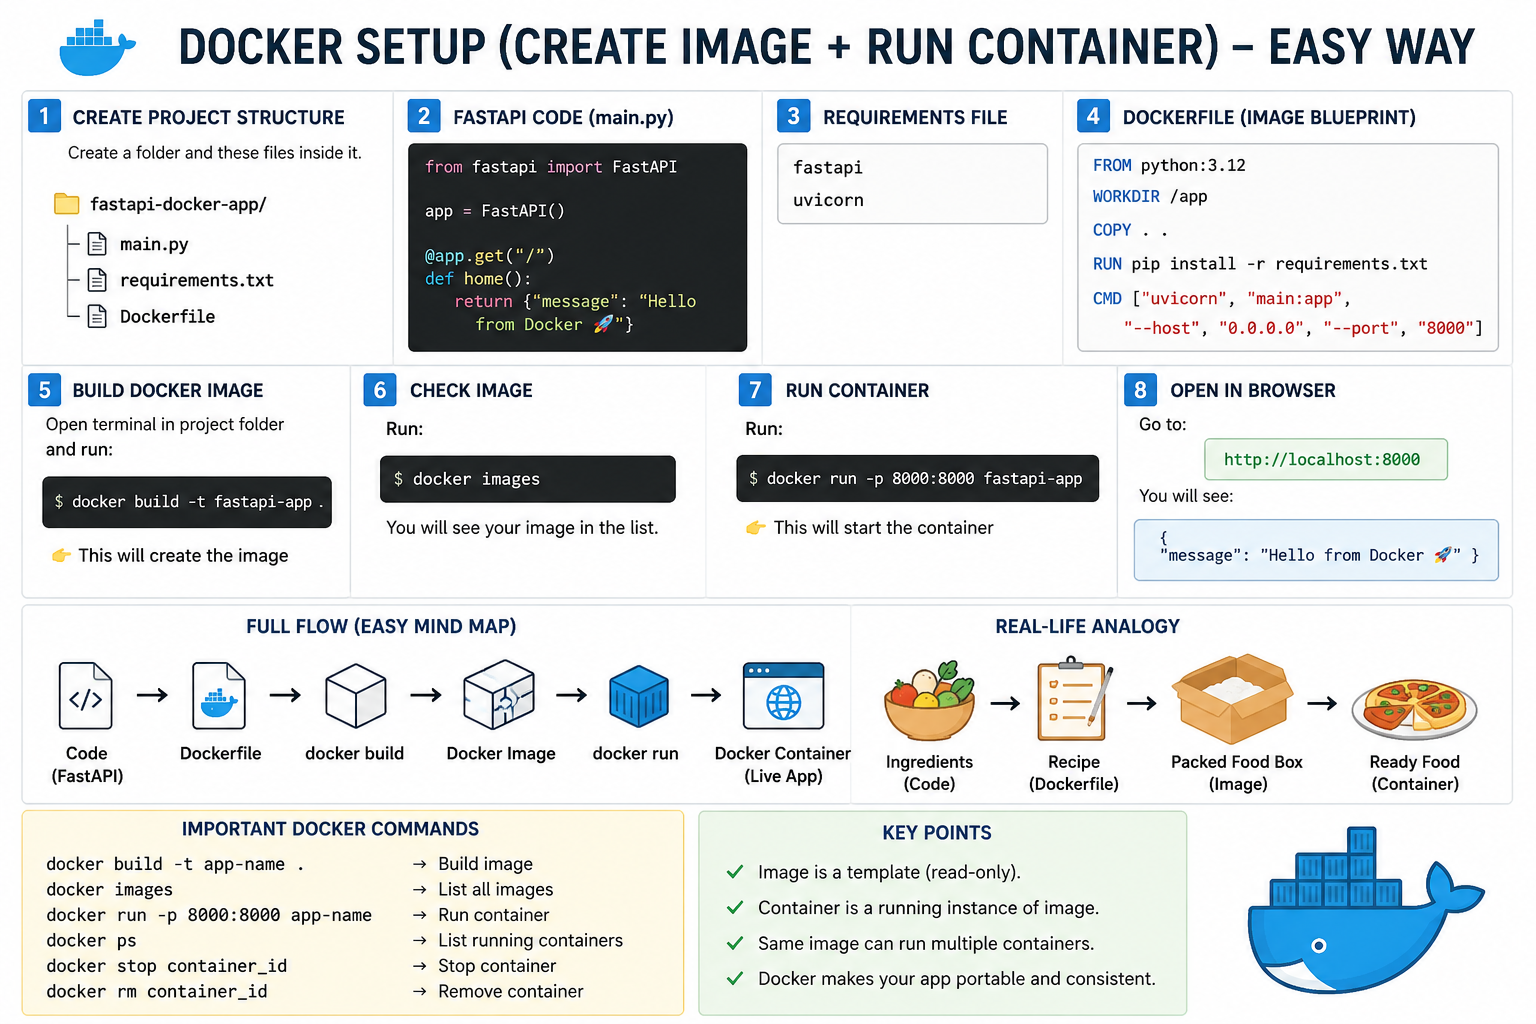

# Docker Hub

Docker Hub ek online platform (registry) hai jahan Docker images store, share aur download ki jati hain.